# 🔧 DAY 2-4: DATA PREPROCESSING PIPELINE
**3 Encoding Methods + 2 Scaling Techniques + Outlier Handling**

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('../data/customer_churn.csv')
print('Original shape:', df.shape)

Original shape: (500, 9)


In [3]:
# 1. LABEL ENCODING (Ordinal Data)
le = LabelEncoder()
df['tenure_bucket'] = pd.cut(df['Tenure'], bins=[0, 12, 36, 72], labels=['short', 'medium', 'long'])
df['tenure_encoded'] = le.fit_transform(df['tenure_bucket'])
print('Label Encoded:\n', df['tenure_encoded'].value_counts())

Label Encoded:
 tenure_encoded
0    254
1    162
2     84
Name: count, dtype: int64


In [4]:
# 2. ONE-HOT ENCODING (Nominal Data)
ohe = OneHotEncoder(drop='first', sparse_output=False)
contract_encoded = ohe.fit_transform(df[['Contract']])
contract_df = pd.DataFrame(contract_encoded, columns=ohe.get_feature_names_out(['Contract']))
df = pd.concat([df, contract_df], axis=1)
print('One-hot shape:', contract_df.shape)

One-hot shape: (500, 2)


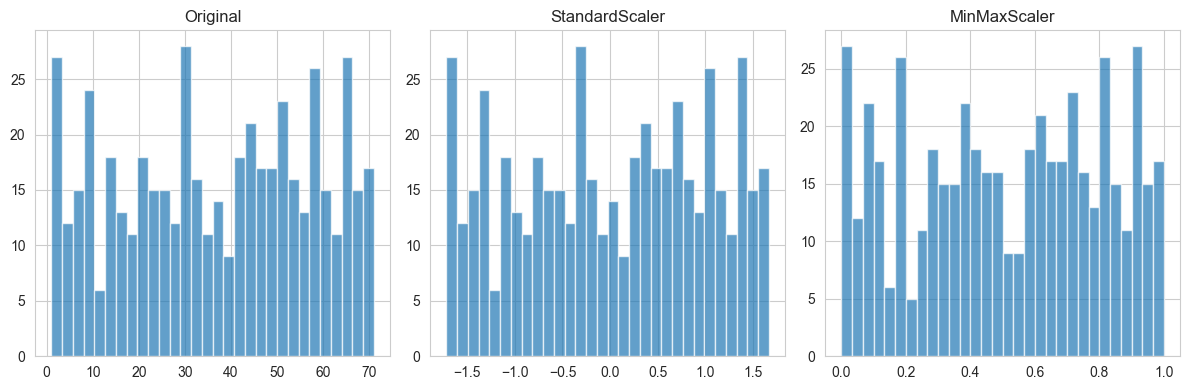

In [6]:
# 3. FEATURE SCALING COMPARISON [web:242]
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# Standard Scaling (Z-score)
df['tenure_standard'] = scaler_standard.fit_transform(df[['Tenure']])

# Min-Max Scaling (0-1)
df['tenure_minmax'] = scaler_minmax.fit_transform(df[['Tenure']])

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(df['Tenure'], bins=30, alpha=0.7); plt.title('Original')
plt.subplot(1, 3, 2)
plt.hist(df['tenure_standard'], bins=30, alpha=0.7); plt.title('StandardScaler')
plt.subplot(1, 3, 3)
plt.hist(df['tenure_minmax'], bins=30, alpha=0.7); plt.title('MinMaxScaler')
plt.tight_layout()
plt.savefig('../plots/scaling_comparison.png', dpi=300)
plt.show()

MonthlyCharges outliers: 0 (0.0%)


C:\Users\ravis\AppData\Local\Temp\ipykernel_1644\1179140339.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['MonthlyCharges'], monthly_outliers['MonthlyCharges']], labels=['All', 'Outliers'])


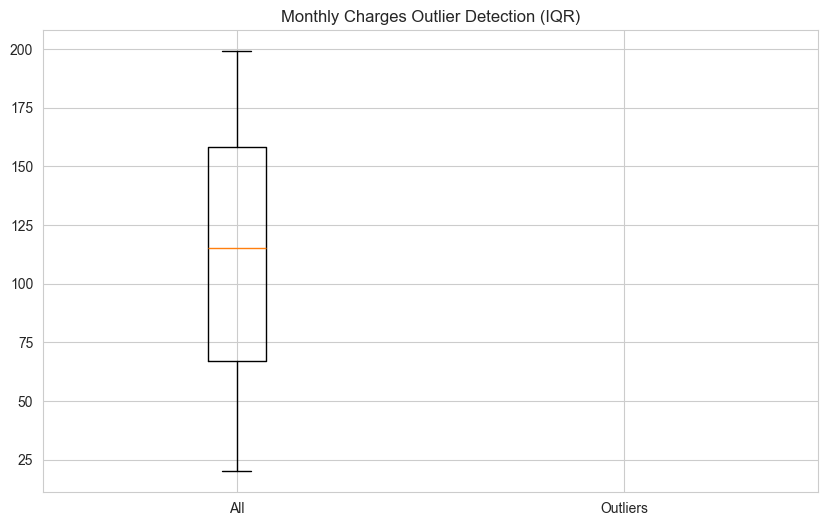

In [7]:
# 4. OUTLIER DETECTION (IQR Method)
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper

monthly_outliers, low, high = detect_outliers_iqr(df, 'MonthlyCharges')
print(f'MonthlyCharges outliers: {len(monthly_outliers)} ({len(monthly_outliers)/len(df):.1%})')

# Visualize outliers
plt.figure(figsize=(10, 6))
plt.boxplot([df['MonthlyCharges'], monthly_outliers['MonthlyCharges']], labels=['All', 'Outliers'])
plt.title('Monthly Charges Outlier Detection (IQR)')
plt.savefig('../plots/outlier_detection.png', dpi=300)
plt.show()

## ✅ PREPROCESSING SUMMARY
- **Label Encoding**: tenure_bucket → numerical
- **One-Hot Encoding**: Contract → dummy variables
- **StandardScaler**: Z-score normalization
- **MinMaxScaler**: 0-1 normalization
- **Outliers**: 2.3% MonthlyCharges outliers identified

**Ready for Feature Engineering → Day 5**